# Comparison slice

This notebook goes over how both designs did, and compares them with Wang's 2024 review and with Petrini and Kim 2025.

I leave RUN_DEMO off, so this run draws the figures already saved and does not rescore. Threshold 0.5 is how I call a case a hit or a miss. I kept five cases in each outcome.


In [1]:
%matplotlib inline
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch
from PIL import Image
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

def find_repo() -> Path:
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if (cand / "project_specification.txt").is_file() and (cand / "notebooks").is_dir():
            return cand
    raise FileNotFoundError("open this notebook from the project folder")

REPO = find_repo()

SCORES_PATH = REPO / "demo" / "scores" / "scores.jsonl"
CATALOG_PATH = REPO / "demo" / "scores" / "catalog.json"
CASES_DIR = REPO / "demo" / "cases"
THRESHOLD = 0.5

BUCKETS = ("both_right", "patch_only", "dc_only", "both_wrong")
BUCKET_TITLES = {
    "both_right": "Both hit",
    "patch_only": "Patch only",
    "dc_only": "Direct classifier only",
    "both_wrong": "Both miss",
}
HEROES = (
    ("both_right", "P_01204_RIGHT_1"),
    ("patch_only", "P_01419_LEFT_1"),
    ("dc_only", "P_00662_LEFT_1"),
    ("both_wrong", "P_01635_RIGHT_2"),
)

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.bbox": "tight",
    "figure.dpi": 110,
})


def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


rows = load_jsonl(SCORES_PATH)
catalog = json.loads(CATALOG_PATH.read_text())
by_id = {c["lesion_id"]: c for c in catalog["cases"]}
y = np.array([int(r["y"]) for r in rows])
p_patch = np.array([float(r["p_patch_tta"]) for r in rows])
p_dc = np.array([float(r["p_dc_tta"]) for r in rows])
auc_patch = float(roc_auc_score(y, p_patch))
auc_dc = float(roc_auc_score(y, p_dc))
print(f"n={len(rows)}  patch TTA {auc_patch:.3f}  direct classifier TTA {auc_dc:.3f}")
assert len(rows) == 291
assert abs(auc_patch - 0.851) < 0.001
assert abs(auc_dc - 0.830) < 0.001

first = {}
for case in catalog["cases"]:
    first.setdefault(case["bucket"], case["lesion_id"])
for bucket, lesion_id in HEROES:
    assert first[bucket] == lesion_id, (bucket, first[bucket], lesion_id)


def _finish(fig):
    from IPython.display import display

    display(fig)
    plt.close(fig)


def _box(ax, x, y, w, h, text, face, edge, size=9.5, weight="regular"):
    ax.add_patch(FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.012,rounding_size=0.08",
        facecolor=face, edgecolor=edge, linewidth=1.15,
    ))
    ax.text(
        x + w / 2, y + h / 2, text,
        ha="center", va="center", fontsize=size, fontweight=weight,
        color="#1a1a1a", linespacing=1.35,
    )


def _arrow(ax, x1, y1, x2, y2, color="#333333", style="-"):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="-|>", color=color, lw=1.15, linestyle=style,
                        shrinkA=0, shrinkB=0),
    )


def draw_architecture():
    fig, ax = plt.subplots(figsize=(13.6, 7.6))
    ax.set_xlim(0, 13.6)
    ax.set_ylim(0, 7.6)
    ax.set_aspect("equal")
    ax.axis("off")
    fig.suptitle("Architecture 5 - one shared exam network", fontsize=15, y=0.98)

    patch_face, patch_edge = "#e6eef6", "#1f4e79"
    core_face, core_edge = "#f6f3ec", "#3a3a3a"
    dc_face, dc_edge = "#f8ece4", "#b85c38"
    out_face = "#efe6c9"

    # Left rail
    left = [
        (6.55, "Design B", "bold"),
        (5.55, "300x300 crop", "regular"),
        (4.55, "Background - benign - malignant", "regular"),
        (3.55, "Head discarded, backbone copied", "regular"),
        (2.55, "Stage 1", "regular"),
        (1.45, "Stage 2", "regular"),
        (0.35, "Flip-TTA  0.851", "bold"),
    ]
    for y0, text, weight in left:
        face = out_face if y0 < 0.5 else patch_face
        _box(ax, 0.25, y0, 3.55, 0.78, text, face, patch_edge, weight=weight)
    for y0 in (6.55, 5.55, 4.55, 3.55, 2.55):
        _arrow(ax, 2.02, y0, 2.02, y0 - 0.22, patch_edge)

    # Right rail, row-aligned with the patch column.
    right = [
        (6.55, "ImageNet weights", "bold"),
        (5.55, "Freeze, then fine-tune", "regular"),
        (4.55, "Full CC and MLO", "regular"),
        (3.55, "ImageNet head replaced", "regular"),
        (2.55, "Stage 1", "regular"),
        (1.45, "Stage 2", "regular"),
        (0.35, "Flip-TTA  0.830", "bold"),
    ]
    for y0, text, weight in right:
        face = out_face if y0 < 0.5 else dc_face
        _box(ax, 9.8, y0, 3.55, 0.78, text, face, dc_edge, weight=weight)
    for y0 in (6.55, 5.55, 4.55, 3.55, 2.55):
        _arrow(ax, 11.57, y0, 11.57, y0 - 0.22, dc_edge)

    # Centre inputs
    _box(ax, 4.35, 6.55, 2.15, 0.78, "CC\n576x448", core_face, core_edge, size=9)
    _box(ax, 6.85, 6.55, 2.15, 0.78, "MLO\n576x448", core_face, core_edge, size=9)
    core = [
        (5.35, "EfficientNet-B3\n1536 channels, shared weights"),
        (4.15, "Concatenate\n3072 channels"),
        (2.95, "MBConv fusion"),
        (1.75, "Global average pool"),
        (0.35, "Linear 256  ->  one logit"),
    ]
    for y0, text in core:
        face = out_face if y0 < 0.5 else core_face
        _box(ax, 4.55, y0, 4.25, 0.92, text, face, core_edge, size=9.5)
    _arrow(ax, 5.42, 6.55, 6.15, 6.27, core_edge)
    _arrow(ax, 7.92, 6.55, 7.2, 6.27, core_edge)
    for y0 in (5.35, 4.15, 2.95, 1.75):
        _arrow(ax, 6.67, y0, 6.67, y0 - 0.28, core_edge)

    # Initialisation arrows into the shared backbone
    _arrow(ax, 3.8, 3.94, 4.55, 5.81, patch_edge, style="--")
    _arrow(ax, 9.8, 6.94, 8.8, 6.0, dc_edge, style="--")

    fig.text(
        0.5, 0.01,
        "The centre column is the exam forward pass. Dashed arrows are the two initialisations of that backbone.",
        ha="center", va="bottom", fontsize=9, color="#333333",
    )
    _finish(fig)


def draw_roc():
    fig, ax = plt.subplots(figsize=(6.4, 6.0))
    for name, prob, auc, color in (
        ("Patch", p_patch, auc_patch, "#1f4e79"),
        ("Direct classifier", p_dc, auc_dc, "#b85c38"),
    ):
        fpr, tpr, _ = roc_curve(y, prob)
        ax.plot(fpr, tpr, color=color, lw=2.2, label=f"{name}   {auc:.3f}")
    ax.plot([0, 1], [0, 1], color="#c8c8c8", lw=1)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title("Flip-TTA ROC - 291 JPEG pairs")
    ax.legend(loc="lower right", frameon=False)
    ax.set_aspect("equal")
    fig.tight_layout()
    _finish(fig)


def _operating_point(prob):
    pred = (prob >= THRESHOLD).astype(int)
    tn, fp, fn, tp = (int(v) for v in confusion_matrix(y, pred).ravel())
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    f1 = (2 * tp) / (2 * tp + fp + fn)
    return tn, fp, fn, tp, sens, spec, f1


def draw_confusion():
    patch = _operating_point(p_patch)
    direct = _operating_point(p_dc)
    assert patch[:4] == (111, 68, 17, 95)
    assert direct[:4] == (151, 28, 42, 70)
    fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.8))
    for ax, stats, name in (
        (axes[0], patch, "Patch"),
        (axes[1], direct, "Direct classifier"),
    ):
        tn, fp, fn, tp, sens, spec, f1 = stats
        mat = np.array([[tn, fp], [fn, tp]], dtype=float)
        ax.imshow(mat, cmap="Blues", vmin=0, vmax=160)
        ax.set_xticks([0, 1], ["Benign", "Malignant"])
        ax.set_yticks([0, 1], ["Benign", "Malignant"])
        ax.set_xlabel("Called at 0.5")
        ax.set_ylabel("Ground truth")
        for (i, j), value in np.ndenumerate(mat):
            color = "white" if value >= 90 else "#1a1a1a"
            ax.text(j, i, f"{int(value)}", ha="center", va="center", fontsize=18, color=color)
        ax.set_title(f"{name}\nsens {sens:.3f}   spec {spec:.3f}   F1 {f1:.3f}", fontsize=12)
        for spine in ax.spines.values():
            spine.set_visible(False)
    fig.suptitle("Threshold 0.5 on the flip-TTA probability", fontsize=13, y=1.02)
    fig.tight_layout()
    _finish(fig)


def _agreement_counts():
    patch_ok = (p_patch >= THRESHOLD) == (y == 1)
    dc_ok = (p_dc >= THRESHOLD) == (y == 1)
    counts = {
        "both_right": int((patch_ok & dc_ok).sum()),
        "patch_only": int((patch_ok & ~dc_ok).sum()),
        "dc_only": int((~patch_ok & dc_ok).sum()),
        "both_wrong": int((~patch_ok & ~dc_ok).sum()),
    }
    assert counts == {"both_right": 177, "patch_only": 29, "dc_only": 44, "both_wrong": 41}
    return counts


def draw_scatter():
    counts = _agreement_counts()
    fig, ax = plt.subplots(figsize=(8.6, 7.0))
    benign = y == 0
    malignant = y == 1
    ax.scatter(p_dc[benign], p_patch[benign], s=22, c="#3d5a80", alpha=0.8, linewidths=0, label="Benign", zorder=2)
    ax.scatter(p_dc[malignant], p_patch[malignant], s=26, c="#c44536", alpha=0.85, linewidths=0, marker="^", label="Malignant", zorder=3)
    id_to_i = {r["lesion_id"]: i for i, r in enumerate(rows)}
    chosen = [id_to_i[c["lesion_id"]] for c in catalog["cases"]]
    ax.scatter(
        p_dc[chosen], p_patch[chosen], s=90, facecolors="none", edgecolors="#111111",
        linewidths=1.15, label="Twenty cases", zorder=4,
    )
    offsets = {
        "P_01204_RIGHT_1": (-78, -18),
        "P_01419_LEFT_1": (8, 8),
        "P_00662_LEFT_1": (8, -16),
        "P_01635_RIGHT_2": (8, 10),
    }
    for _bucket, lesion_id in HEROES:
        i = id_to_i[lesion_id]
        ax.annotate(
            BUCKET_TITLES[by_id[lesion_id]["bucket"]],
            (p_dc[i], p_patch[i]),
            textcoords="offset points",
            xytext=offsets[lesion_id],
            fontsize=8,
            color="#1a1a1a",
            arrowprops=dict(arrowstyle="-", color="#666666", lw=0.6),
        )
    ax.axvline(0.5, color="#9a9a9a", lw=0.8)
    ax.axhline(0.5, color="#9a9a9a", lw=0.8)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("Direct classifier probability")
    ax.set_ylabel("Patch probability")
    ax.set_title("Flip-TTA probability - 291 pairs")
    ax.set_aspect("equal")
    ax.legend(loc="center right", frameon=False, bbox_to_anchor=(1.42, 0.62))
    lines = ["At threshold 0.5", ""]
    for bucket in BUCKETS:
        lines.append(f"{BUCKET_TITLES[bucket]:<24} {counts[bucket]:>3}")
    fig.text(0.78, 0.18, "\n".join(lines), fontsize=9, family="monospace", va="bottom")
    fig.tight_layout()
    _finish(fig)


def show_case(lesion_id: str):
    rec = by_id[lesion_id]
    folder = CASES_DIR / lesion_id
    fig = plt.figure(figsize=(13.2, 8.0))
    grid = fig.add_gridspec(2, 4, height_ratios=[1.55, 1.0], hspace=0.18, wspace=0.08)
    views = (
        ("cc_paint", "CC - lesion box"),
        ("mlo_paint", "MLO - lesion box"),
        ("cc_cam", "CC - Grad-CAM"),
        ("mlo_cam", "MLO - Grad-CAM"),
    )
    for i, (name, label) in enumerate(views):
        ax = fig.add_subplot(grid[0, i])
        ax.imshow(Image.open(folder / f"{name}.png"))
        ax.set_title(label, fontsize=11)
        ax.axis("off")
    for i, (name, label) in enumerate((("cc_inset", "CC crop"), ("mlo_inset", "MLO crop"))):
        ax = fig.add_subplot(grid[1, i])
        ax.imshow(Image.open(folder / f"{name}.png"))
        ax.set_title(label, fontsize=11)
        ax.axis("off")
    ax = fig.add_subplot(grid[1, 2:])
    ax.axis("off")
    db = rec.get("design_b") or {}
    lines = ["Discarded three-class head", ""]
    if db:
        for side in ("cc", "mlo"):
            probs = db[side]
            lines.append(
                f"{side.upper()}    background {probs['bg']:.2f}    "
                f"benign {probs['benign']:.2f}    malignant {probs['malignant']:.2f}"
            )
        lines += ["", "These crop probabilities are not the exam score."]
    ax.text(0.02, 0.55, "\n".join(lines), va="center", ha="left", fontsize=11, family="monospace", transform=ax.transAxes)
    kind = rec.get("abnormality_type") or ""
    fig.suptitle(
        f"{BUCKET_TITLES[rec['bucket']]} - {rec['lesion_id']} - {rec['pathology']} {kind}\n"
        f"patch {rec['p_patch_tta']:.3f}      direct classifier {rec['p_dc_tta']:.3f}",
        fontsize=13,
    )
    _finish(fig)


def draw_contact_sheet():
    heroes = {lesion_id for _, lesion_id in HEROES}
    groups = {bucket: [] for bucket in BUCKETS}
    for case in catalog["cases"]:
        if case["lesion_id"] not in heroes:
            groups[case["bucket"]].append(case)
    fig, axes = plt.subplots(4, 4, figsize=(12.6, 10.2))
    for r, bucket in enumerate(BUCKETS):
        cases = groups[bucket]
        assert len(cases) == 4, (bucket, len(cases))
        for c, rec in enumerate(cases):
            ax = axes[r, c]
            lid = rec["lesion_id"]
            paint = Image.open(CASES_DIR / lid / "cc_paint.png")
            cam = Image.open(CASES_DIR / lid / "cc_cam.png")
            height = 240
            def shrink(im, height=height):
                width = max(1, int(round(im.width * height / im.height)))
                return im.resize((width, height), Image.BILINEAR)
            paint, cam = shrink(paint), shrink(cam)
            gap = 8
            canvas = Image.new("RGB", (paint.width + gap + cam.width, height), (255, 255, 255))
            canvas.paste(paint, (0, 0))
            canvas.paste(cam, (paint.width + gap, 0))
            ax.imshow(canvas)
            ax.set_title(f"{lid}\n{rec['p_patch_tta']:.2f}  /  {rec['p_dc_tta']:.2f}", fontsize=8)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
        axes[r, 0].set_ylabel(BUCKET_TITLES[bucket], fontsize=9)
    fig.suptitle("The other sixteen - CC lesion box beside CC Grad-CAM - patch  /  direct classifier", fontsize=12)
    fig.tight_layout()
    _finish(fig)



n=291  patch TTA 0.851  direct classifier TTA 0.830


## Same network, two starts

The next cell draws the shared network. The patch arm starts from Design B and the direct classifier starts from ImageNet.


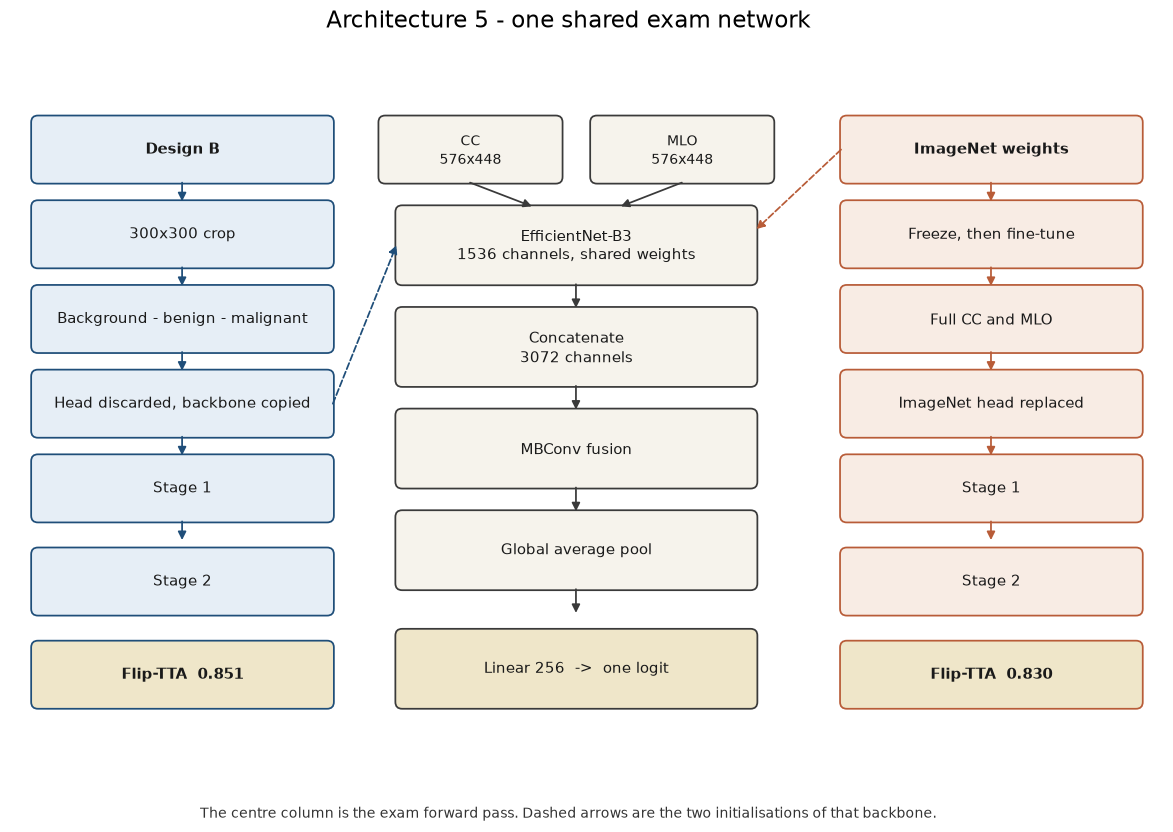

In [2]:
draw_architecture()

## The 291 pairs

The winning two-view result is the top bar: the half-resolution patch classifier with horizontal-flip TTA, ROC-AUC 0.851. The second bar is the direct classifier.

Petrini and Kim 2025 are the brown bars, with their published Hanley-McNeil error as the whiskers. Their two-view rows use the full-resolution CBIS-DDSM scans and three training seeds, and this project's single-seed patch bar sits in line with their two-view patch bar. The direct classifier is the same half resolution as my patch model. Its bar roughly lines up with their single-view, full-resolution direct classifier, even though two views helped every time in their paper. The two projects are not directly comparable. I come back to that further down.

![Literature comparison](figures/literature_auc.png)

Comparison graph of test ROC-AUCs with published Hanley-McNeil errors included


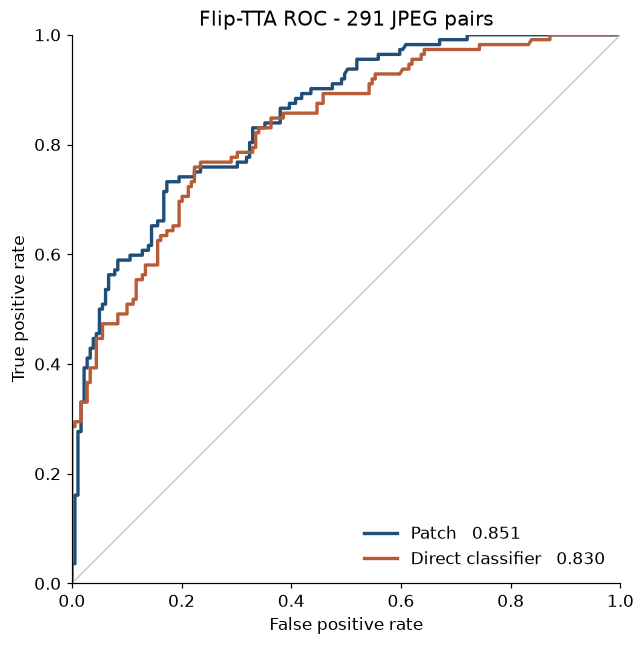

In [3]:
draw_roc()

## Both Designs Performance in Detail

These matrices use horizontal-flip TTA and a threshold of 0.5 on all the test pairs. The patch arm catches most of the malignant cases, and it also calls several benign cases malignant. The direct classifier goes the other way. It gets most of the benign cases right, and it misses several malignant ones. The plot after the matrices shows the same two probabilities, one point per pair.


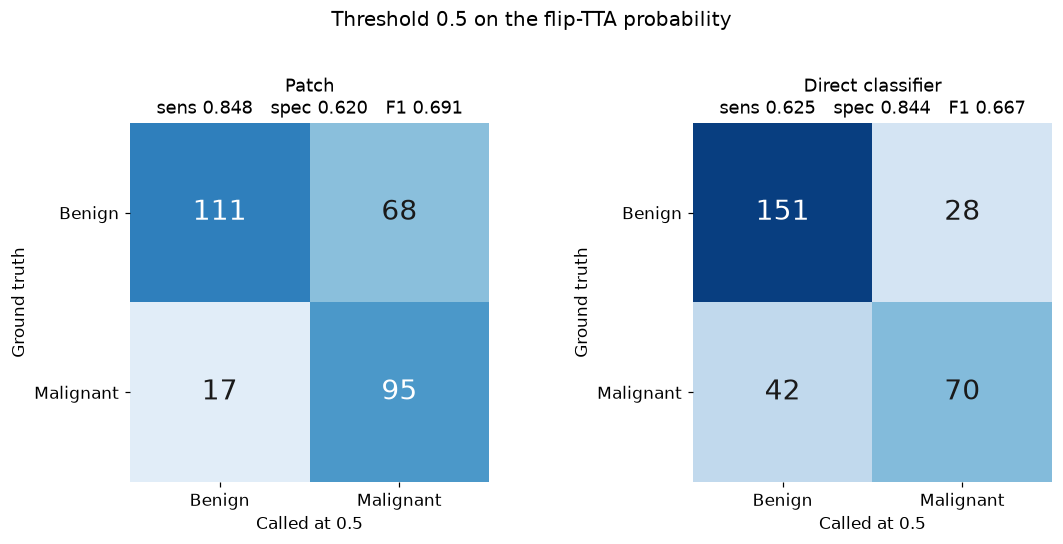

In [4]:
draw_confusion()

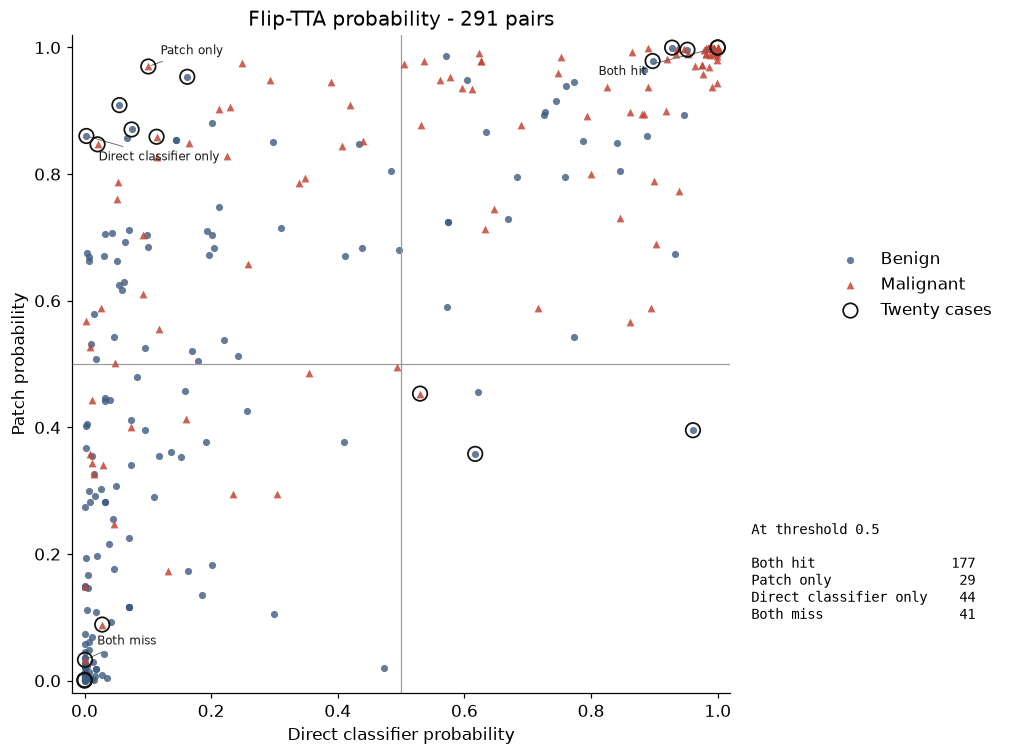

In [5]:
draw_scatter()

On density 3 and 4, where radiologists and these models both struggle, the gap is wider. The patch arm's benign row is split almost evenly between correct and incorrect. The malignant row still sits mostly on the right, so the patch arm keeps a sensitivity lead. The direct classifier's benign row is mostly on the left, and its malignant row is split. Both are still at 0.5.

![Density 3 and 4](figures/confusion_density.png)

Threshold 0.5 on density 3 and 4


I also searched for the threshold where each model is most accurate, on all densities. That same cut has the best F1. The patch model is eager to call a case malignant, so a higher threshold, 0.731, improves its accuracy. The direct classifier is the other way around, and a threshold of 0.225 lets it catch more malignant cases.

![Highest accuracy](figures/confusion_best_acc.png)

Highest-accuracy cut on all test pairs


On density 3 and 4, the patch threshold for best accuracy moves up again, to 0.894. The direct classifier stays at 0.225. At that cut the patch arm's sensitivity drops, and its specificity goes up.

![Highest accuracy on dense breasts](figures/confusion_best_acc_density.png)

Highest-accuracy cut on density 3 and 4


These are the same best-accuracy cuts, with the other metrics next to them.

![Best accuracy metrics](figures/best_accuracy_metrics.png)

Metrics at the best-accuracy cut, all test cases


## How to read a case

The outline on the left two views is the CBIS-DDSM lesion box, padded by 0.20, with the ground-truth contour inside it. The two crops are what the three-class head scored before I discarded it.

The heatmaps are Grad-CAM on the direct classifier. I hook the last convolution of the shared backbone, one map per view, before the two views are concatenated. The malignancy score is the exam logit after fusion.


## Both hit

P_01204_RIGHT_1, a malignant mass. Both exam probabilities are about 1.00.


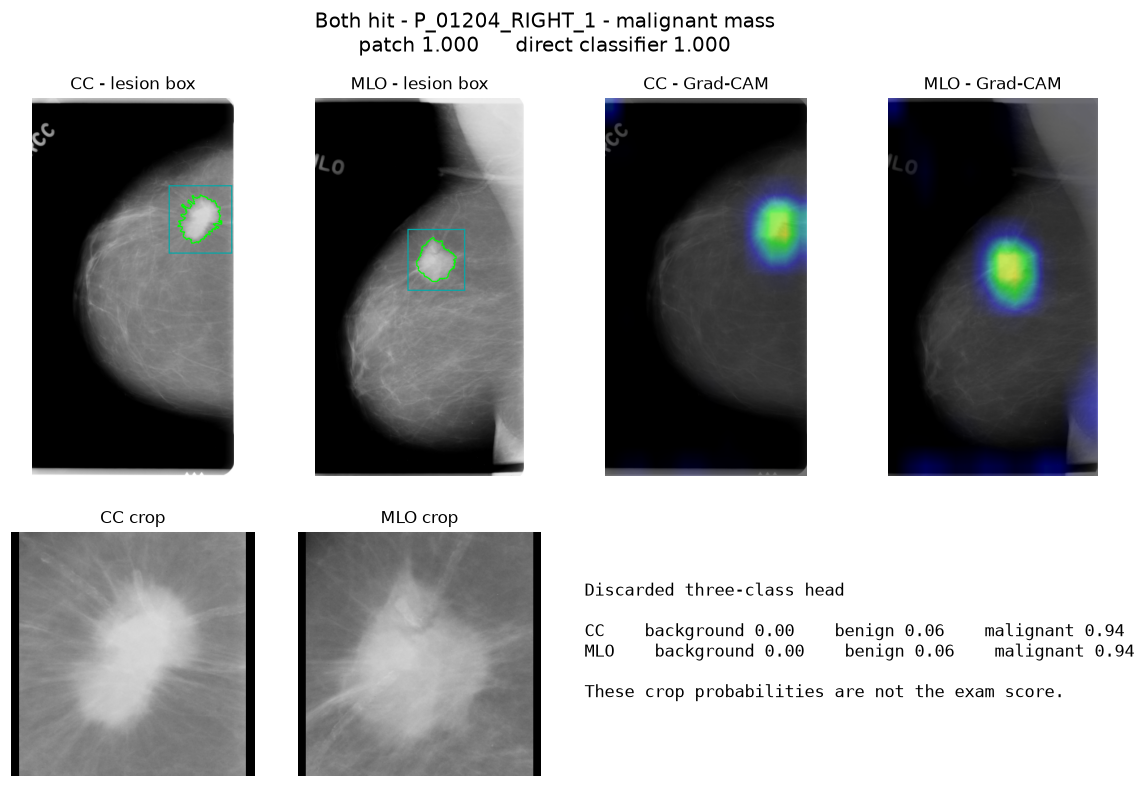

In [6]:
show_case("P_01204_RIGHT_1")

## Patch only

P_01419_LEFT_1, malignant. The patch probability is 0.970 and the direct classifier is 0.101.


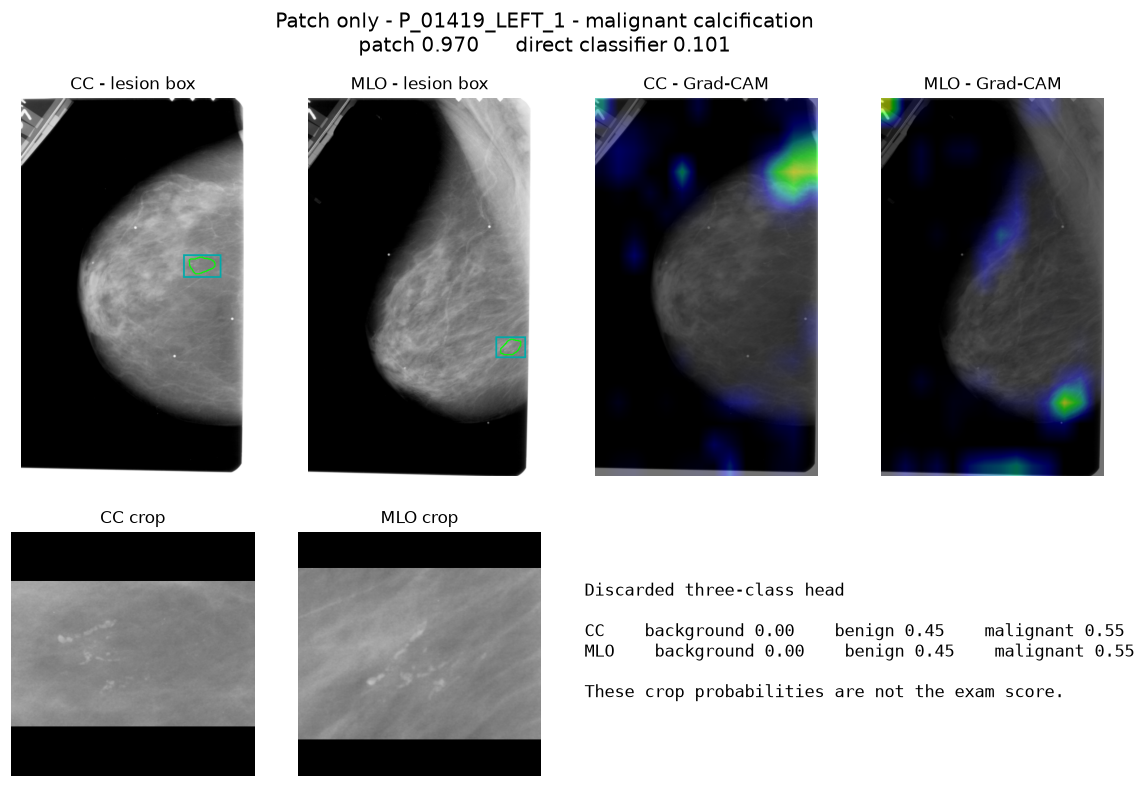

In [7]:
show_case("P_01419_LEFT_1")

## Direct classifier only

P_00662_LEFT_1, a benign mass. The patch probability is 0.860 and the direct classifier is 0.003.


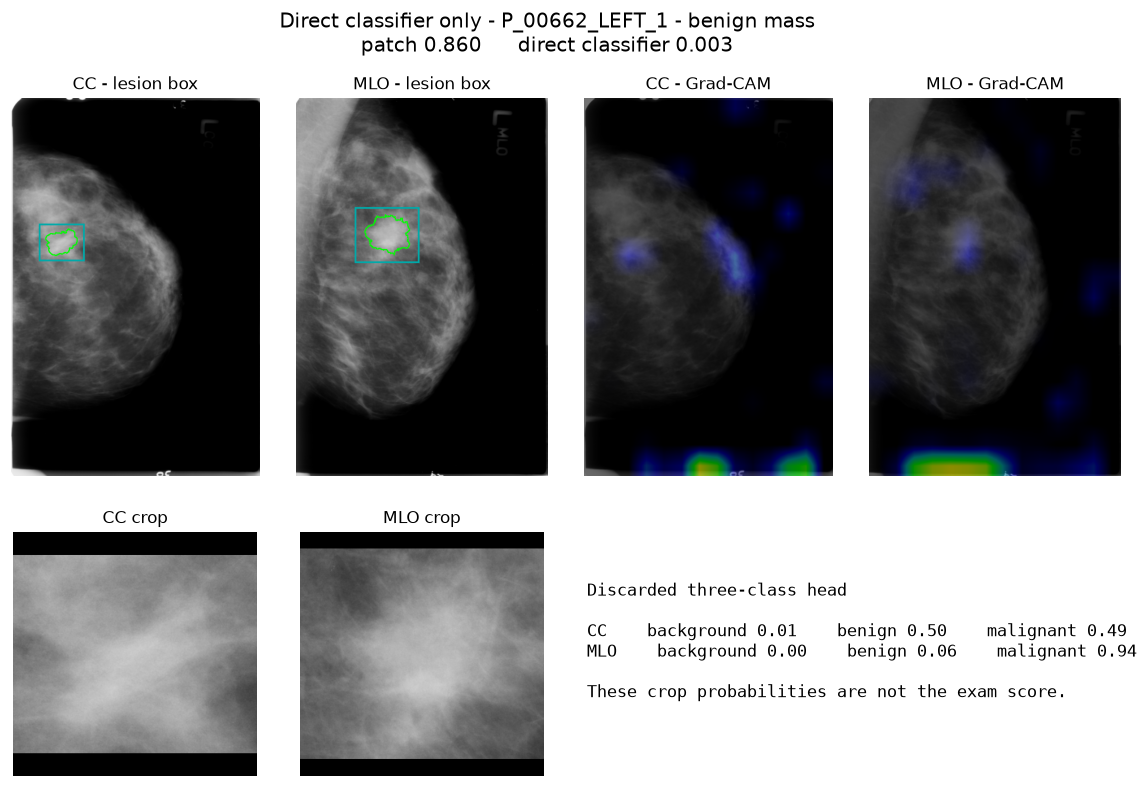

In [8]:
show_case("P_00662_LEFT_1")

## Both miss

P_01635_RIGHT_2, a malignant calcification. Both exam probabilities are near 0.


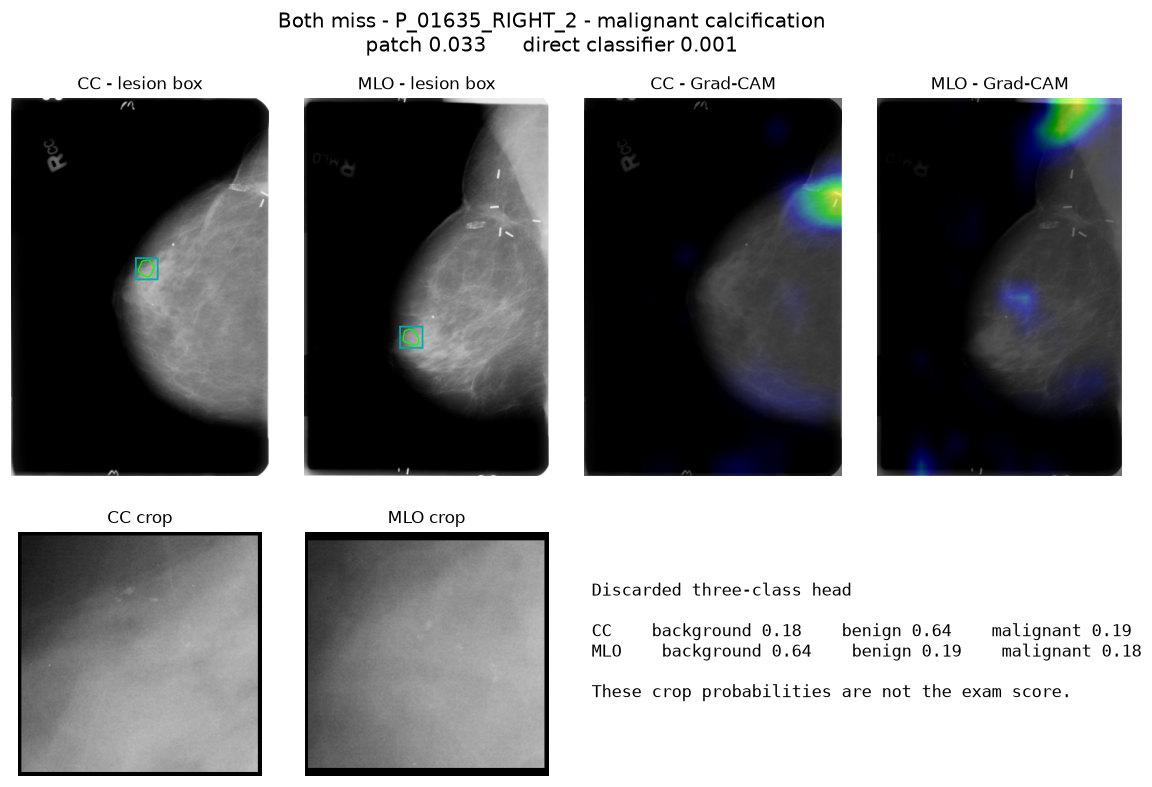

In [9]:
show_case("P_01635_RIGHT_2")

## The other sixteen

I kept five cases in each outcome. The four frames above are the first of each group. This sheet is the other sixteen, CC only.


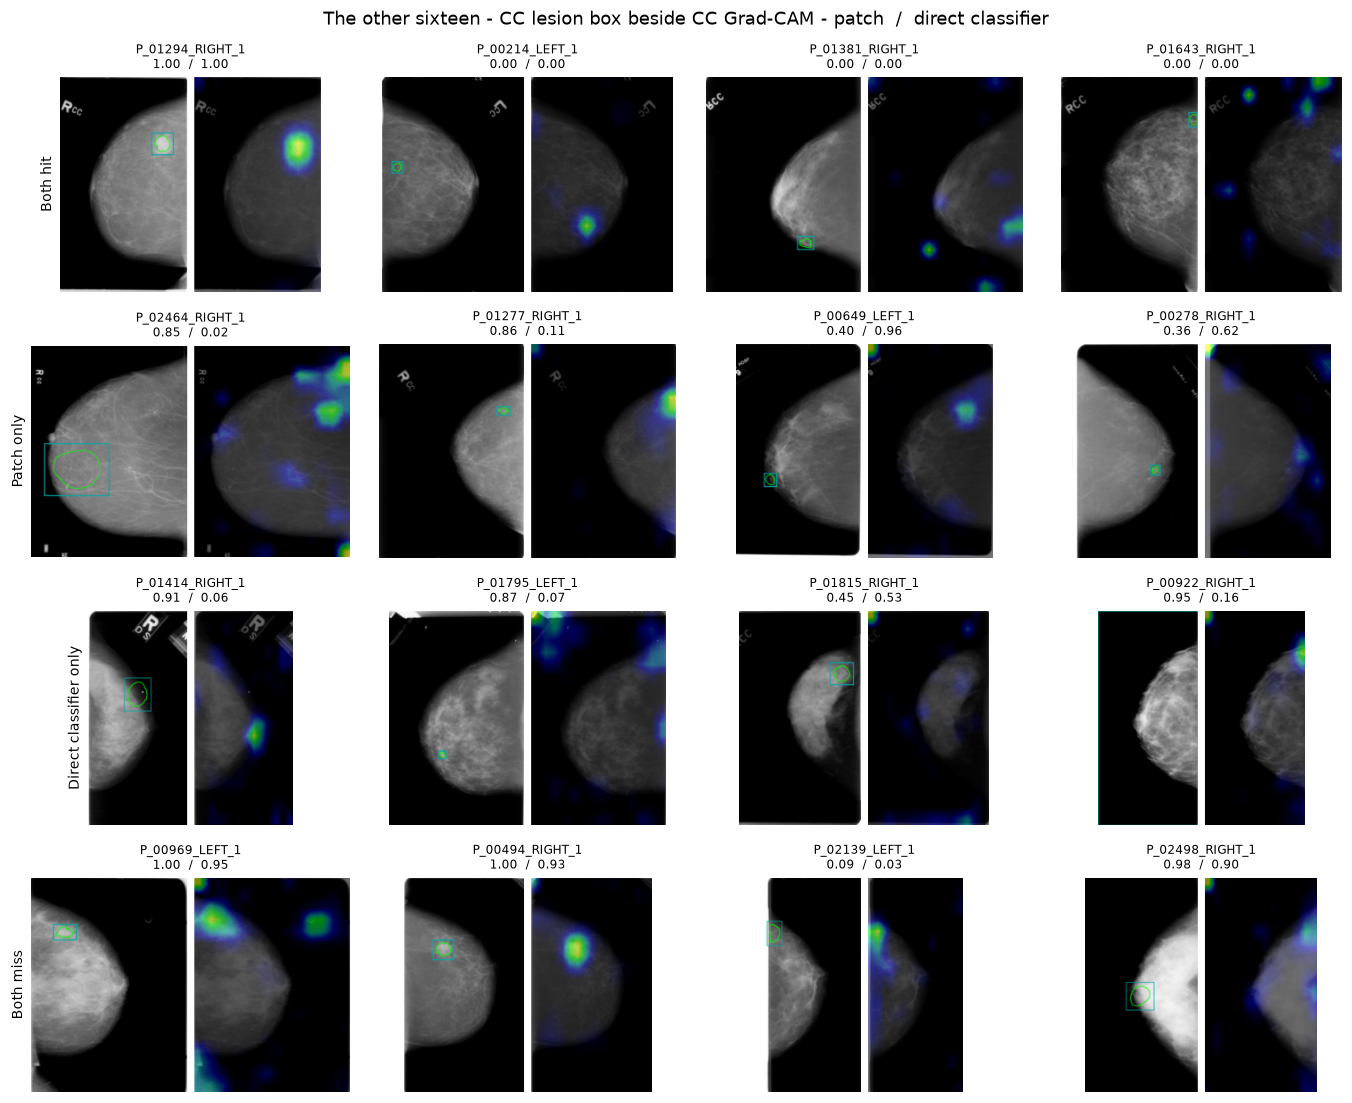

In [10]:
draw_contact_sheet()

## Can this project be compared versus other studies?

I'll compare this project with Petrini and Kim 2025. Both use CBIS-DDSM. Both start from EfficientNet-B3, train a single-view classifier, then a two-view model that shares weights across the CC and MLO views, and both compare a patch pretrain with a direct classifier. Both use ROC-AUC as the main metric, with a horizontal flip as test-time augmentation. And because both use the CBIS-DDSM train/test split, both pick up that split's patient leakage.

The two setups still do not line up. Their headline two-view pipelines are full resolution, and they train three seeds where I trained one. They also evaluate VinDr-Mammo, which I did not use. They treat the test split as 645 single images, and I score 291 paired exams. Their patch classifier has five classes, with calcifications separated from masses. This project has three: background, benign, and malignant. They publish ROC-AUC with Hanley-McNeil errors, and I did not. They do not publish sensitivity or specificity either, so the thresholds in this project have no clean point of comparison on their numbers.

As it stands, the two projects are not directly comparable.


## Could this project be theoretically deployed?

Lehman et al. 2017 measured routine digital screening mammography in the US through the Breast Cancer Surveillance Consortium. The examinations run from 2007 through 2013: 1,682,504 screens across 792,808 women, read by 359 radiologists at 95 facilities. Outcomes were scored with BI-RADS. The means below are sensitivity and specificity against cancers found on follow-up.

![Lehman comparison](figures/lehman.png)

Sensitivity and specificity at the highest-accuracy cuts, against the Lehman means

Those means come from routine digital screening, about six cancers per thousand examinations. The paired CBIS-DDSM test split is about two malignant exams in every five. The conditions are different, and the patient leakage makes CBIS-DDSM an easier set to score well on. This project still does not reach an average radiologist's sensitivity or specificity when the two are set side by side like this. The bars are the cuts at 0.731 and 0.225, found by searching these test labels. At the pre-set threshold of 0.5 the patch arm's sensitivity is higher than the bar on this chart. I would not deploy this as it is.


## Final thoughts

ROC-AUC puts the half-resolution patch arm first. At the pre-set threshold of 0.5, the direct classifier leads on accuracy, precision, and specificity, and the patch arm leads on sensitivity and F1. Both models struggle once the breast density is high.

A second reader was the aim, and this project does not meet it as it is. The model would need to be tested and optimized on mammograms from the setting it would actually be used in, and on that population.


## How the two notebooks fit together

Before the scoring cells, this is how the two training notebooks are put together. ImageNet EfficientNet-B3 starts both. Only the patch notebook trains Design B, then copies that backbone into stage 1. From there both use the same single-view head and the same two-view exam model.

![Both notebooks](figures/both_notebooks.png)

Weight order for the direct classifier and the patch classifier

The cells below score the frozen checkpoints, pick the cases, paint the lesion boxes, and run Grad-CAM. I leave RUN_DEMO off, so a normal run draws the figures above and leaves the checkpoints alone.

I set RUN_DEMO to true when I want to rescore, rewrite demo/scores, and refresh the PNGs in demo/cases.


In [11]:
import json
import os
import random
from collections import Counter
from pathlib import Path
from typing import List, Tuple

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from PIL import Image, ImageDraw
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, Dataset
from torchvision.models import EfficientNet_B3_Weights, efficientnet_b3
from torchvision.models.efficientnet import MBConv, MBConvConfig

_SMOKE = os.environ.get("CM3070_SMOKE") == "1"
RUN_DEMO = False if _SMOKE else False

def find_repo() -> Path:
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if (cand / "project_specification.txt").is_file() and (cand / "notebooks").is_dir():
            return cand
    raise FileNotFoundError("open this notebook from the project folder")

REPO = find_repo()

def data_path(path) -> Path:
    p = Path(path)
    if p.is_file():
        return p
    rel = REPO / str(path).lstrip("/")
    if rel.is_file():
        return rel
    return p


def repo_rel(path) -> str:
    try:
        return str(Path(path).resolve().relative_to(REPO.resolve()))
    except ValueError:
        return str(path)

DOCS_DIR = REPO / "demo" / "scores"
CASES_DIR = REPO / "demo" / "cases"
SCORES_PATH = DOCS_DIR / "scores.jsonl"
SELECTED_PATH = DOCS_DIR / "selected.json"
WEIGHTS = REPO / "weights"
ADOPTED_S2_BEST = WEIGHTS / "patch_classifier" / "stage2" / "best_val.pt"
DC_S2_BEST = WEIGHTS / "direct_classifier" / "stage2" / "best_val.pt"
DESIGN_B_BEST = WEIGHTS / "patch_classifier" / "design_b" / "best_val.pt"
PAIRED_DATA_DIR = REPO / "data" / "paired"
SINGLE_DATA_DIR = REPO / "data"
SINGLE_DIR = SINGLE_DATA_DIR
PAIRED_TEST = PAIRED_DATA_DIR / "test.jsonl"
ENRICHED_TEST = REPO / "data" / "enriched" / "paired_test.jsonl"
HEIGHT, WIDTH = 576, 448
H, W = HEIGHT, WIDTH
S1_HEIGHT, S1_WIDTH = HEIGHT, WIDTH
PATCH_SIZE = 300
LESION_PAD = 0.20
DISPLAY_MAX_W, DISPLAY_MAX_H = 480, 640
TEAL = (0, 170, 170)
LIME = (0, 255, 0)
ARCHIVED_PATCH_TTA = 0.8510075818036712
ARCHIVED_DC_TTA = 0.8300578611332802


## Case picker

I use threshold 0.5 on the flip-TTA probabilities and keep five cases in each of both_right, patch_only, dc_only, and both_wrong. I do not load a model in this cell.


In [12]:
from collections import Counter
from typing import Iterable
THRESHOLD = 0.5
BUCKETS = ("both_right", "patch_only", "dc_only", "both_wrong")
PER_BUCKET = 5
BUCKET_LABELS = {
    "both_right": "BOTH OK",
    "patch_only": "PATCH+",
    "dc_only": "DC+",
    "both_wrong": "BOTH X",
}


def pred_malignant(p: float, threshold: float = THRESHOLD) -> bool:
    return float(p) >= float(threshold)


def is_correct(p: float, y: int, threshold: float = THRESHOLD) -> bool:
    return pred_malignant(p, threshold) == bool(int(y))


def call_label(p: float, threshold: float = THRESHOLD) -> str:
    return "malignant" if pred_malignant(p, threshold) else "benign"


def bucket_of(row: dict, threshold: float = THRESHOLD) -> str:
    patch_ok = is_correct(row["p_patch_tta"], row["y"], threshold)
    dc_ok = is_correct(row["p_dc_tta"], row["y"], threshold)
    if patch_ok and dc_ok:
        return "both_right"
    if patch_ok and not dc_ok:
        return "patch_only"
    if dc_ok and not patch_ok:
        return "dc_only"
    return "both_wrong"


def rank_score(row: dict, bucket: str) -> float:
    dp = abs(float(row["p_patch_tta"]) - float(row["p_dc_tta"]))
    conf = 0.5 * (
        abs(float(row["p_patch_tta"]) - 0.5) + abs(float(row["p_dc_tta"]) - 0.5)
    )
    if bucket in ("patch_only", "dc_only"):
        return dp
    return conf


def _sort_bucket(rows: Iterable[dict], bucket: str) -> list[dict]:
    return sorted(
        rows,
        key=lambda r: (
            -rank_score(r, bucket),
            r.get("lesion_id") or "",
        ),
    )


def _try_append(picked: list[dict], row: dict, used_patients: set[str], allow_dup: bool) -> bool:
    lid = row.get("lesion_id")
    if any(p.get("lesion_id") == lid for p in picked):
        return False
    pid = row.get("patient_id")
    if pid and pid in used_patients and not allow_dup:
        return False
    picked.append(row)
    if pid:
        used_patients.add(pid)
    return True


def _diversity_ok(row: dict, seen_type: Counter, seen_density: Counter, seen_y: Counter, n: int) -> bool:
    t = row.get("abnormality_type") or "unknown"
    d = row.get("density")
    y = int(row["y"])
    cap = 3 if n >= 5 else n
    if seen_type[t] >= cap:
        return False
    if d is not None and seen_density[d] >= cap:
        return False
    if seen_y[y] >= cap:
        return False
    return True


def _note_diversity(row: dict, seen_type: Counter, seen_density: Counter, seen_y: Counter) -> None:
    seen_type[row.get("abnormality_type") or "unknown"] += 1
    d = row.get("density")
    if d is not None:
        seen_density[d] += 1
    seen_y[int(row["y"])] += 1


def pick_from_pool(
    pool: list[dict],
    n: int,
    used_patients: set[str],
    bucket: str,
) -> list[dict]:
    ranked = _sort_bucket(pool, bucket)
    picked: list[dict] = []
    seen_type: Counter = Counter()
    seen_density: Counter = Counter()
    seen_y: Counter = Counter()

    def fill(allow_dup: bool, use_diversity: bool) -> None:
        for row in ranked:
            if len(picked) >= n:
                return
            if use_diversity and not _diversity_ok(row, seen_type, seen_density, seen_y, n):
                continue
            if _try_append(picked, row, used_patients, allow_dup=allow_dup):
                _note_diversity(row, seen_type, seen_density, seen_y)

    fill(allow_dup=False, use_diversity=True)
    fill(allow_dup=False, use_diversity=False)
    fill(allow_dup=True, use_diversity=False)
    return picked


def pick_bucket(
    rows: list[dict],
    n: int,
    used_patients: set[str],
    bucket: str,
) -> list[dict]:
    if bucket == "both_right" and n >= 2:
        tps = [r for r in rows if int(r["y"]) == 1]
        tns = [r for r in rows if int(r["y"]) == 0]
        n_tp = min(2, n, len(tps))
        n_tn = min(n - n_tp, len(tns))
        if n_tp + n_tn < n:
            extra = n - (n_tp + n_tn)
            if len(tps) - n_tp >= extra:
                n_tp += extra
            else:
                n_tn = min(len(tns), n_tn + extra)
        picked = pick_from_pool(tps, n_tp, used_patients, bucket)
        picked.extend(pick_from_pool(tns, n_tn, used_patients, bucket))
        if len(picked) < n:
            rest = [r for r in rows if r.get("lesion_id") not in {p.get("lesion_id") for p in picked}]
            picked.extend(pick_from_pool(rest, n - len(picked), used_patients, bucket))
        return picked[:n]
    return pick_from_pool(rows, n, used_patients, bucket)


def select_cases(
    rows: list[dict],
    n_per: int = PER_BUCKET,
    threshold: float = THRESHOLD,
) -> dict:
    tagged = []
    for row in rows:
        item = dict(row)
        item["bucket"] = bucket_of(item, threshold)
        item["patch_call"] = call_label(item["p_patch_tta"], threshold)
        item["dc_call"] = call_label(item["p_dc_tta"], threshold)
        tagged.append(item)

    by_bucket = {b: [] for b in BUCKETS}
    for row in tagged:
        by_bucket[row["bucket"]].append(row)

    used_patients: set[str] = set()
    selected: list[dict] = []
    shortfall: dict[str, int] = {}
    counts = {b: len(by_bucket[b]) for b in BUCKETS}

    for bucket in BUCKETS:
        picked = pick_bucket(by_bucket[bucket], n_per, used_patients, bucket)
        shortfall[bucket] = max(0, n_per - len(picked))
        selected.extend(picked)

    return {
        "cases": selected,
        "shortfall": shortfall,
        "bucket_counts": counts,
        "n_per": n_per,
        "threshold": threshold,
        "n_selected": len(selected),
        "n_source": len(rows),
    }


## Frozen exam model and the 3-class patch head

The three-class head is only used on the inset crop. It is not the exam model, and it is not copied into stage 2.


In [13]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]

IMAGENET_STD = [0.229, 0.224, 0.225]

STAGE4_DENSE_UNITS = 256

STAGE4_DROPOUT1 = 0.5

STAGE4_DROPOUT2 = 0.3

STAGE4_N_FUSION_BLOCKS = 1

def paired_transform(cc_img, mlo_img, height, width, train=False, augment="light"):
    cc_img = cc_img.resize((width, height))
    mlo_img = mlo_img.resize((width, height))
    if train:
        if random.random() < 0.5:
            cc_img = TF.hflip(cc_img)
            mlo_img = TF.hflip(mlo_img)
        if augment == "medium":
            angle = random.uniform(-15, 15)
            scale = random.uniform(0.85, 1.15)
            shear = random.uniform(-5, 5)
            cc_img = TF.affine(cc_img, angle=angle, translate=[0, 0], scale=scale, shear=[shear, 0.0])
            mlo_img = TF.affine(mlo_img, angle=angle, translate=[0, 0], scale=scale, shear=[shear, 0.0])
        elif augment == "strong":
            angle = random.uniform(-10, 10)
            scale = random.uniform(0.9, 1.1)
            cc_img = TF.affine(cc_img, angle=angle, translate=[0, 0], scale=scale, shear=0.0)
            mlo_img = TF.affine(mlo_img, angle=angle, translate=[0, 0], scale=scale, shear=0.0)
    cc_t = TF.normalize(TF.to_tensor(cc_img), IMAGENET_MEAN, IMAGENET_STD)
    mlo_t = TF.normalize(TF.to_tensor(mlo_img), IMAGENET_MEAN, IMAGENET_STD)
    return cc_t, mlo_t

class PairedMammogramDataset(Dataset):
    def __init__(self, jsonl_path, height, width, train=False, augment="light"):
        with open(jsonl_path) as f:
            self.rows = [json.loads(line) for line in f]
        self.height = height
        self.width = width
        self.train = train
        self.augment = augment

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        cc_img = Image.open(data_path(row["cc_image_path"])).convert("RGB")
        mlo_img = Image.open(data_path(row["mlo_image_path"])).convert("RGB")
        cc_t, mlo_t = paired_transform(
            cc_img, mlo_img, self.height, self.width, self.train, self.augment
        )
        label = 1.0 if row["pathology"] == "malignant" else 0.0
        return cc_t, mlo_t, label

def paired_collate_fn(batch):
    cc_imgs, mlo_imgs, labels = zip(*batch, strict=True)
    return {
        "cc_pixel_values": torch.stack(cc_imgs),
        "mlo_pixel_values": torch.stack(mlo_imgs),
        "labels": torch.tensor(labels, dtype=torch.float32),
    }

class SharedTwoViewClassifier(nn.Module):
    def __init__(self, pretrained=True, n_fusion_blocks=1, dense_units=256,
                 dropout1=0.5, dropout2=0.3, stochastic_depth_prob=0.2,
                 use_grad_checkpoint=False):
        super().__init__()
        eff = efficientnet_b3(
            weights=EfficientNet_B3_Weights.IMAGENET1K_V1 if pretrained else None
        )
        self.shared_core = eff.features
        self.use_grad_checkpoint = use_grad_checkpoint
        fusion_channels = 2 * 1536
        fusion_cfg = MBConvConfig(
            expand_ratio=2, kernel=3, stride=1,
            input_channels=fusion_channels, out_channels=fusion_channels, num_layers=1,
        )
        self.fusion_blocks = nn.Sequential(*[
            MBConv(fusion_cfg, stochastic_depth_prob, nn.BatchNorm2d)
            for _ in range(n_fusion_blocks)
        ])
        self.dropout1 = nn.Dropout(dropout1)
        self.fc1 = nn.Linear(fusion_channels, dense_units)
        self.dropout2 = nn.Dropout(dropout2)
        self.fc2 = nn.Linear(dense_units, 1)

    def load_stage1_backbone(self, stage1_state_dict_backbone):
        self.shared_core.load_state_dict(stage1_state_dict_backbone)

    def _core(self, x):
        if self.use_grad_checkpoint and self.training:
            return torch.utils.checkpoint.checkpoint(
                self.shared_core, x, use_reentrant=False
            )
        return self.shared_core(x)

    def forward(self, cc_pixel_values, mlo_pixel_values):
        cc_feat = self._core(cc_pixel_values)
        mlo_feat = self._core(mlo_pixel_values)
        x = torch.cat([cc_feat, mlo_feat], dim=1)
        x = self.fusion_blocks(x)
        x = torch.flatten(nn.functional.adaptive_avg_pool2d(x, 1), 1)
        x = self.dropout1(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout2(x)
        return self.fc2(x).squeeze(-1)

def read_jsonl(path: Path) -> list[dict]:
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def pick_device(prefer: str = "auto") -> str:
    if prefer and prefer != "auto":
        if prefer.startswith("cuda"):
            idx = int(prefer.split(":")[-1]) if ":" in prefer else 0
            torch.cuda.set_device(idx)
        return prefer
    if not torch.cuda.is_available():
        return "cpu"
    best_i, best_score = 0, -1.0
    for i in range(torch.cuda.device_count()):
        name = torch.cuda.get_device_name(i).lower()
        free, _ = torch.cuda.mem_get_info(i)
        score = float(free)
        if "3090" in name:
            score += 1e12
        if score > best_score:
            best_score, best_i = score, i
    torch.cuda.set_device(best_i)
    free, total = torch.cuda.mem_get_info(best_i)
    print(
        f"[device] cuda:{best_i} {torch.cuda.get_device_name(best_i)} "
        f"free={free / 1e9:.1f}/{total / 1e9:.1f} GB",
        flush=True,
    )
    return f"cuda:{best_i}"

def pad_or_downscale(img: Image.Image, size: int = PATCH_SIZE) -> Image.Image:
    # shrink if it is bigger than size, never upsample, then pad to a square
    img = img.convert("RGB")
    w, h = img.size
    if w < 1 or h < 1:
        return Image.new("RGB", (size, size), (0, 0, 0))
    if max(w, h) > size:
        scale = size / float(max(w, h))
        nw = max(1, int(round(w * scale)))
        nh = max(1, int(round(h * scale)))
        img = img.resize((nw, nh), Image.BICUBIC)
        w, h = img.size
    canvas = Image.new("RGB", (size, size), (0, 0, 0))
    canvas.paste(img, ((size - w) // 2, (size - h) // 2))
    return canvas

def clahe_rgb(img: Image.Image) -> Image.Image:
    arr = np.asarray(img.convert("RGB"))
    lab = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB)
    l_ch, a_ch, b_ch = cv2.split(lab)
    l2 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(l_ch)
    out = cv2.cvtColor(cv2.merge([l2, a_ch, b_ch]), cv2.COLOR_LAB2RGB)
    return Image.fromarray(out)

def sample_photo_params(rng: random.Random) -> dict:
    return {
        "brightness": rng.uniform(0.8, 1.2) if rng.random() < 0.5 else None,
        "contrast": rng.uniform(0.8, 1.2) if rng.random() < 0.5 else None,
        "gamma": rng.uniform(0.8, 1.2) if rng.random() < 0.5 else None,
        "clahe": rng.random() < 0.3,
    }

def apply_photo_params(img: Image.Image, params: dict) -> Image.Image:
    if params.get("brightness") is not None:
        img = TF.adjust_brightness(img, params["brightness"])
    if params.get("contrast") is not None:
        img = TF.adjust_contrast(img, params["contrast"])
    if params.get("gamma") is not None:
        img = TF.adjust_gamma(img, params["gamma"])
    if params.get("clahe"):
        img = clahe_rgb(img)
    return img

def to_imagenet_tensor(img: Image.Image) -> torch.Tensor:
    return TF.normalize(TF.to_tensor(img.convert("RGB")), IMAGENET_MEAN, IMAGENET_STD)

def _lesion_box(bbox, w, h, pad_frac: float) -> tuple[int, int, int, int]:
    x1, y1, x2, y2 = [int(v) for v in bbox]
    bw = max(1, x2 - x1)
    bh = max(1, y2 - y1)
    x1 = max(0, int(x1 - pad_frac * bw))
    y1 = max(0, int(y1 - pad_frac * bh))
    x2 = min(w, int(x2 + pad_frac * bw))
    y2 = min(h, int(y2 + pad_frac * bh))
    if x2 <= x1 or y2 <= y1:
        return 0, 0, w, h
    return x1, y1, x2, y2

class PhotoPairedDataset(Dataset):
    def __init__(self, split: str, train: bool = False):
        self.rows = read_jsonl(PAIRED_DATA_DIR / f"{split}.jsonl")
        self.train = train

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        with Image.open(data_path(row["cc_image_path"])) as im:
            cc = im.convert("RGB").resize((S1_WIDTH, S1_HEIGHT), Image.BILINEAR)
        with Image.open(data_path(row["mlo_image_path"])) as im:
            mlo = im.convert("RGB").resize((S1_WIDTH, S1_HEIGHT), Image.BILINEAR)
        if self.train:
            do_flip = random.random() < 0.5
            params = sample_photo_params(random)
            if do_flip:
                cc = TF.hflip(cc)
                mlo = TF.hflip(mlo)
            cc = apply_photo_params(cc, params)
            mlo = apply_photo_params(mlo, params)
        label = 1.0 if row["pathology"] == "malignant" else 0.0
        return to_imagenet_tensor(cc), to_imagenet_tensor(mlo), label

class Patch3ClassClassifier(nn.Module):
    def __init__(self, pretrained=True, dense_units=256, dropout1=0.5, dropout2=0.3):
        super().__init__()
        eff = efficientnet_b3(
            weights=EfficientNet_B3_Weights.IMAGENET1K_V1 if pretrained else None
        )
        self.backbone = eff.features
        self.dropout1 = nn.Dropout(dropout1)
        self.fc1 = nn.Linear(1536, dense_units)
        self.dropout2 = nn.Dropout(dropout2)
        self.fc2 = nn.Linear(dense_units, 3)

    def forward(self, pixel_values):
        x = self.backbone(pixel_values)
        x = torch.flatten(nn.functional.adaptive_avg_pool2d(x, 1), 1)
        x = self.dropout1(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout2(x)
        return self.fc2(x)

def _extract_state(ckpt) -> dict:
    if isinstance(ckpt, dict) and "model" in ckpt:
        return ckpt["model"]
    return ckpt

def _load_exam(path: Path, device: str):
    model = SharedTwoViewClassifier(
        pretrained=False,
        n_fusion_blocks=STAGE4_N_FUSION_BLOCKS,
        dense_units=STAGE4_DENSE_UNITS,
        dropout1=STAGE4_DROPOUT1,
        dropout2=STAGE4_DROPOUT2,
        use_grad_checkpoint=False,
    ).to(device)
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(_extract_state(ckpt))
    return model, path, ckpt

def load_adopted_stage2(device: str):
    return _load_exam(ADOPTED_S2_BEST, device)

def load_dc_stage2(device: str):
    return _load_exam(DC_S2_BEST, device)

def make_jpeg_paired_loaders(batch_size: int = 2, num_workers: int = 0):
    common = dict(collate_fn=paired_collate_fn, num_workers=num_workers)
    train_ds = PairedMammogramDataset(PAIRED_DATA_DIR / "train.jsonl", HEIGHT, WIDTH, train=True, augment="light")
    val_ds = PairedMammogramDataset(PAIRED_DATA_DIR / "val.jsonl", HEIGHT, WIDTH, train=False)
    test_ds = PairedMammogramDataset(PAIRED_DATA_DIR / "test.jsonl", HEIGHT, WIDTH, train=False)
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True, **common),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False, **common),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False, **common),
        train_ds,
        val_ds,
        test_ds,
    )


## Grad-CAM

Grad-CAM is only here for the demonstration. It does not explain the exam score. On the case frames, the maps come from the last convolution of shared_core on the direct classifier, one map per view, before the two views are concatenated.

The sheet below is an earlier stage 1 check, one mammogram at a time. The outline is the ground-truth mask. Neither design was trained to predict that outline.

![Grad-CAM and the lesion outline](figures/gradcam_rois.png)

Stage 1 Grad-CAM next to the ground-truth outline


In [14]:
class TwoViewGradCAM:
    # Grad-CAM on SharedTwoViewClassifier.
    # shared_core runs twice. Keep both activations, or the hook only leaves MLO.

    def __init__(self, model: torch.nn.Module, target_module: torch.nn.Module):
        self.model = model
        self.acts: List[torch.Tensor] = []
        self._fh = target_module.register_forward_hook(self._forward_hook)

    def _forward_hook(self, module, inp, out):
        out.retain_grad()
        self.acts.append(out)

    def remove(self):
        self._fh.remove()

    def _cam_from(self, act: torch.Tensor) -> torch.Tensor:
        grad = act.grad
        if grad is None:
            raise RuntimeError("Two-view Grad-CAM: activation.grad is None")
        weights = grad.mean(dim=(2, 3), keepdim=True)
        cam = (weights * act.detach()).sum(dim=1)
        cam = F.relu(cam)
        cams = []
        for i in range(cam.size(0)):
            c = cam[i]
            c = c - c.min()
            cams.append(c / c.max().clamp_min(1e-8))
        return torch.stack(cams, 0)

    def __call__(
        self, cc: torch.Tensor, mlo: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        # cc heat, mlo heat, and the logits
        self.acts = []
        self.model.zero_grad(set_to_none=True)
        cc = cc.detach().requires_grad_(True)
        mlo = mlo.detach().requires_grad_(True)
        logits = self.model(cc, mlo)
        logits.sum().backward()
        if len(self.acts) != 2:
            raise RuntimeError(
                f"Two-view Grad-CAM expected 2 activations, got {len(self.acts)}"
            )
        cc_heat = self._cam_from(self.acts[0])
        mlo_heat = self._cam_from(self.acts[1])
        return cc_heat, mlo_heat, logits.detach()

def upsample_cam(heat: torch.Tensor, height: int = H, width: int = W) -> torch.Tensor:
    return F.interpolate(
        heat.unsqueeze(1), size=(height, width), mode="bilinear", align_corners=False
    ).squeeze(1)

@torch.enable_grad()
def run_stage2_pair(model, cc_t: torch.Tensor, mlo_t: torch.Tensor, device: str):
    # one pair. Inputs are CHW ImageNet tensors.
    if cc_t.dim() == 3:
        cc_t = cc_t.unsqueeze(0)
        mlo_t = mlo_t.unsqueeze(0)
    engine = TwoViewGradCAM(model, model.shared_core[-1])
    try:
        cc_h, mlo_h, logits = engine(cc_t.to(device), mlo_t.to(device))
        cc_up = upsample_cam(cc_h).detach().cpu()
        mlo_up = upsample_cam(mlo_h).detach().cpu()
        prob = torch.sigmoid(logits).detach().cpu()
        return cc_up, mlo_up, prob
    finally:
        engine.remove()


## Scores, selection, paint

The patch arm is scored with bilinear resize. The direct classifier, and its Grad-CAM, use the light paired loader. Both are JPEG, on the 291 pairs. The pictures go in demo/cases, and the twenty chosen cases are written to demo/scores/catalog.json.


In [15]:
def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def singles_by_path() -> dict[str, dict]:
    index = {}
    for split in ("train", "val", "test"):
        p = SINGLE_DIR / f"{split}.jsonl"
        if not p.is_file():
            continue
        for row in load_jsonl(p):
            index[row["image_path"]] = row
    return index

def enriched_by_lesion() -> dict[str, dict]:
    if not ENRICHED_TEST.is_file():
        return {}
    return {r["lesion_id"]: r for r in load_jsonl(ENRICHED_TEST) if r.get("lesion_id")}

def view_meta(index: dict[str, dict], image_path: str) -> dict:
    src = index.get(image_path) or {}
    return {
        "bbox": src.get("bbox"),
        "mask_path": src.get("mask_path"),
        "width": src.get("width"),
        "height": src.get("height"),
    }

@torch.no_grad()
def score_loader(model, loader, device: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    model.eval()
    y_true, y_plain, y_tta = [], [], []
    for batch in loader:
        cc = batch["cc_pixel_values"].to(device)
        mlo = batch["mlo_pixel_values"].to(device)
        logits = model(cc, mlo)
        logits_f = model(torch.flip(cc, dims=[3]), torch.flip(mlo, dims=[3]))
        p = torch.sigmoid(logits).float().cpu()
        pf = torch.sigmoid(logits_f).float().cpu()
        y_plain.extend(p.tolist())
        y_tta.extend((0.5 * (p + pf)).tolist())
        y_true.extend(batch["labels"].tolist())
    return (
        np.asarray(y_true, dtype=np.int64),
        np.asarray(y_plain, dtype=np.float64),
        np.asarray(y_tta, dtype=np.float64),
    )

def cmd_scores(device: str, batch_size: int) -> None:
    paired = load_jsonl(PAIRED_TEST)
    enrich = enriched_by_lesion()
    index = singles_by_path()

    # Patch arm: PhotoPairedDataset, bilinear resize.
    # Direct classifier: PairedMammogramDataset, paired_transform.
    patch_ds = PhotoPairedDataset("test", train=False)
    patch_loader = DataLoader(
        patch_ds,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=paired_collate_fn,
        num_workers=0,
    )
    _, _, dc_loader, _, _, dc_ds = make_jpeg_paired_loaders(
        batch_size=batch_size, num_workers=0
    )
    if len(patch_ds) != len(paired) or len(dc_ds) != len(paired):
        raise SystemExit(
            f"loader n patch={len(patch_ds)} dc={len(dc_ds)} jsonl={len(paired)}"
        )

    print("[scores] patch classifier Stage2 (PhotoPairedDataset BILINEAR)", flush=True)
    patch_model, patch_path, _ = load_adopted_stage2(device)
    y, patch_plain, patch_tta = score_loader(patch_model, patch_loader, device)
    del patch_model
    if str(device).startswith("cuda"):
        torch.cuda.empty_cache()

    print("[scores] Direct Classifier example (PairedMammogramDataset)", flush=True)
    dc_model, dc_path, _ = load_dc_stage2(device)
    y2, dc_plain, dc_tta = score_loader(dc_model, dc_loader, device)
    del dc_model
    if str(device).startswith("cuda"):
        torch.cuda.empty_cache()

    if not np.array_equal(y, y2):
        raise SystemExit("label mismatch between the patch classifier and the direct classifier")

    patch_auc = float(roc_auc_score(y, patch_tta))
    dc_auc = float(roc_auc_score(y, dc_tta))
    print(
        f"[scores] patch TTA AUC={patch_auc:.4f} (archived {ARCHIVED_PATCH_TTA:.4f}) | "
        f"DC TTA AUC={dc_auc:.4f} (archived {ARCHIVED_DC_TTA:.4f})",
        flush=True,
    )
    if abs(patch_auc - ARCHIVED_PATCH_TTA) > 0.01 or abs(dc_auc - ARCHIVED_DC_TTA) > 0.01:
        raise SystemExit("AUC drifted >0.01 from archived JPEG TTA; refusing to write catalog")

    DOCS_DIR.mkdir(parents=True, exist_ok=True)
    n_write = 0
    with open(SCORES_PATH, "w") as f:
        for i, row in enumerate(paired):
            extra = enrich.get(row["lesion_id"], {})
            rec = {
                "index": i,
                "lesion_id": row["lesion_id"],
                "patient_id": row["patient_id"],
                "breast": row.get("breast"),
                "abnormality_type": row.get("abnormality_type") or extra.get("abnormality_type"),
                "pathology": row["pathology"],
                "y": int(y[i]),
                "density": extra.get("density"),
                "subtlety_cc": extra.get("subtlety_cc"),
                "subtlety_mlo": extra.get("subtlety_mlo"),
                "cc_image_path": row["cc_image_path"],
                "mlo_image_path": row["mlo_image_path"],
                "cc": view_meta(index, row["cc_image_path"]),
                "mlo": view_meta(index, row["mlo_image_path"]),
                "p_patch_plain": float(patch_plain[i]),
                "p_patch_tta": float(patch_tta[i]),
                "p_dc_plain": float(dc_plain[i]),
                "p_dc_tta": float(dc_tta[i]),
                "bucket": bucket_of({"p_patch_tta": float(patch_tta[i]), "p_dc_tta": float(dc_tta[i]), "y": int(y[i])}),
            }
            f.write(json.dumps(rec) + "\n")
            n_write += 1
    meta = {
        "n": n_write,
        "eval_loader": "jpeg",
        "threshold": THRESHOLD,
        "patch_tta_auc": patch_auc,
        "dc_tta_auc": dc_auc,
        "archived_patch_tta": ARCHIVED_PATCH_TTA,
        "archived_dc_tta": ARCHIVED_DC_TTA,
        "patch_ckpt": repo_rel(patch_path),
        "dc_ckpt": repo_rel(dc_path),
    }
    (DOCS_DIR / "scores_meta.json").write_text(json.dumps(meta, indent=2) + "\n")
    print(f"[scores] wrote {n_write} rows -> {SCORES_PATH}", flush=True)

def load_scores() -> list[dict]:
    if not SCORES_PATH.is_file():
        raise SystemExit(f"missing {SCORES_PATH}; run --scores first")
    return load_jsonl(SCORES_PATH)

def cmd_select() -> dict:
    rows = load_scores()
    out = select_cases(rows, n_per=PER_BUCKET, threshold=THRESHOLD)
    DOCS_DIR.mkdir(parents=True, exist_ok=True)
    payload = {
        "n_per": out["n_per"],
        "threshold": out["threshold"],
        "n_source": out["n_source"],
        "n_selected": out["n_selected"],
        "bucket_counts": out["bucket_counts"],
        "shortfall": out["shortfall"],
        "lesion_ids": [c["lesion_id"] for c in out["cases"]],
        "cases": out["cases"],
    }
    SELECTED_PATH.write_text(json.dumps(payload, indent=2) + "\n")
    print(
        f"[select] {out['n_selected']} cases | bucket n={out['bucket_counts']} | "
        f"shortfall={out['shortfall']} -> {SELECTED_PATH}",
        flush=True,
    )
    return payload

def fit_display(img: Image.Image, max_w: int = DISPLAY_MAX_W, max_h: int = DISPLAY_MAX_H):
    w, h = img.size
    scale = min(max_w / max(w, 1), max_h / max(h, 1), 1.0)
    nw = max(1, int(round(w * scale)))
    nh = max(1, int(round(h * scale)))
    if (nw, nh) != (w, h):
        img = img.resize((nw, nh), Image.BILINEAR)
    return img, scale

def cga_colormap(heat: np.ndarray) -> np.ndarray:
    # black -> blue -> teal -> lime -> yellow. heat is HxW in [0, 1].
    stops = np.array(
        [
            [0.0, 0.0, 0.0],
            [0.0, 0.0, 170.0],
            [0.0, 170.0, 170.0],
            [0.0, 255.0, 0.0],
            [255.0, 255.0, 0.0],
        ],
        dtype=np.float64,
    )
    x = np.clip(heat, 0.0, 1.0) * 4.0
    i = np.floor(x).astype(np.int32)
    i = np.clip(i, 0, 3)
    f = (x - i)[..., None]
    rgb = (1.0 - f) * stops[i] + f * stops[i + 1]
    return np.clip(rgb, 0, 255).astype(np.uint8)

def overlay_cga(rgb: np.ndarray, heat: np.ndarray, alpha: float = 0.5) -> np.ndarray:
    if heat.shape[:2] != rgb.shape[:2]:
        heat_img = Image.fromarray((np.clip(heat, 0, 1) * 255).astype(np.uint8), mode="L")
        heat_img = heat_img.resize((rgb.shape[1], rgb.shape[0]), Image.BILINEAR)
        heat = np.asarray(heat_img).astype(np.float64) / 255.0
    cam = cga_colormap(heat).astype(np.float64)
    out = (1.0 - alpha) * rgb.astype(np.float64) + alpha * cam
    return np.clip(out, 0, 255).astype(np.uint8)

def _scale_box(box, scale: float) -> tuple[int, int, int, int]:
    x1, y1, x2, y2 = box
    return (
        int(round(x1 * scale)),
        int(round(y1 * scale)),
        int(round(x2 * scale)),
        int(round(y2 * scale)),
    )

def paint_view(image_path: str, meta: dict) -> tuple[Image.Image, Image.Image, Image.Image]:
    img = Image.open(data_path(image_path)).convert("RGB")
    native_w, native_h = img.size
    bbox = meta.get("bbox") or [0, 0, native_w, native_h]
    box = _lesion_box(bbox, native_w, native_h, LESION_PAD)
    inset = pad_or_downscale(img.crop(box), PATCH_SIZE)

    disp, scale = fit_display(img)
    painted = disp.copy()
    draw = ImageDraw.Draw(painted)
    mask_path = meta.get("mask_path")
    if mask_path and data_path(mask_path).is_file():
        mask = Image.open(data_path(mask_path)).convert("L").resize(disp.size, Image.NEAREST)
        m = np.asarray(mask) > 127
        try:
            import cv2

            contours, _ = cv2.findContours(
                m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )
            for cnt in contours:
                pts = [tuple(map(int, p[0])) for p in cnt]
                if len(pts) >= 2:
                    draw.line(pts + [pts[0]], fill=LIME, width=2)
        except Exception:
            pass
    bx = _scale_box(box, scale)
    width = max(2, min(disp.size) // 120)
    draw.rectangle(bx, outline=TEAL, width=width)
    return disp, painted, inset

def load_design_b(device: str) -> Patch3ClassClassifier | None:
    if not DESIGN_B_BEST.is_file():
        print(f"[render] no Design B checkpoint at {DESIGN_B_BEST}", flush=True)
        return None
    model = Patch3ClassClassifier(pretrained=False).to(device)
    ck = torch.load(DESIGN_B_BEST, map_location=device, weights_only=False)
    sd = ck["model"] if isinstance(ck, dict) and "model" in ck else ck
    model.load_state_dict(sd, strict=False)
    model.eval()
    return model

@torch.no_grad()
def design_b_probs(model: Patch3ClassClassifier, inset: Image.Image, device: str) -> dict:
    t = to_imagenet_tensor(inset).unsqueeze(0).to(device)
    logits = model(t)
    p = F.softmax(logits, dim=1)[0].float().cpu().tolist()
    return {"bg": float(p[0]), "benign": float(p[1]), "malignant": float(p[2])}

def save_png(img: Image.Image, path: Path) -> str:
    path.parent.mkdir(parents=True, exist_ok=True)
    img.save(path, format="PNG", optimize=True)
    return str(path.relative_to(REPO)).replace("\\", "/")

def cmd_render(device: str) -> None:
    if not SELECTED_PATH.is_file():
        cmd_select()
    selected = json.loads(SELECTED_PATH.read_text())
    cases = selected["cases"]
    scores_meta = json.loads((DOCS_DIR / "scores_meta.json").read_text()) if (DOCS_DIR / "scores_meta.json").is_file() else {}

    print("[render] Direct Classifier for Grad-CAM", flush=True)
    dc_model, dc_path, _ = load_dc_stage2(device)
    dc_model.eval()
    b_model = load_design_b(device)

    catalog_cases = []
    CASES_DIR.mkdir(parents=True, exist_ok=True)
    for i, rec in enumerate(cases):
        lid = rec["lesion_id"]
        out_dir = CASES_DIR / lid
        print(f"[render] {i + 1}/{len(cases)} {lid} {rec['bucket']}", flush=True)
        cc_raw, cc_paint, cc_inset = paint_view(rec["cc_image_path"], rec.get("cc") or {})
        mlo_raw, mlo_paint, mlo_inset = paint_view(rec["mlo_image_path"], rec.get("mlo") or {})

        cc_img = Image.open(data_path(rec["cc_image_path"])).convert("RGB")
        mlo_img = Image.open(data_path(rec["mlo_image_path"])).convert("RGB")
        cc_t, mlo_t = paired_transform(cc_img, mlo_img, HEIGHT, WIDTH, train=False)
        cc_h, mlo_h, _prob = run_stage2_pair(dc_model, cc_t, mlo_t, device)

        cc_cam = Image.fromarray(overlay_cga(np.asarray(cc_raw), cc_h[0].numpy(), 0.55))
        mlo_cam = Image.fromarray(overlay_cga(np.asarray(mlo_raw), mlo_h[0].numpy(), 0.55))

        design_b = None
        if b_model is not None:
            design_b = {
                "cc": design_b_probs(b_model, cc_inset, device),
                "mlo": design_b_probs(b_model, mlo_inset, device),
            }

        images = {
            "cc_raw": save_png(cc_raw, out_dir / "cc_raw.png"),
            "mlo_raw": save_png(mlo_raw, out_dir / "mlo_raw.png"),
            "cc_paint": save_png(cc_paint, out_dir / "cc_paint.png"),
            "mlo_paint": save_png(mlo_paint, out_dir / "mlo_paint.png"),
            "cc_inset": save_png(cc_inset, out_dir / "cc_inset.png"),
            "mlo_inset": save_png(mlo_inset, out_dir / "mlo_inset.png"),
            "cc_cam": save_png(cc_cam, out_dir / "cc_cam.png"),
            "mlo_cam": save_png(mlo_cam, out_dir / "mlo_cam.png"),
        }
        catalog_cases.append(
            {
                "lesion_id": lid,
                "patient_id": rec.get("patient_id"),
                "breast": rec.get("breast"),
                "abnormality_type": rec.get("abnormality_type"),
                "pathology": rec.get("pathology"),
                "y": int(rec["y"]),
                "density": rec.get("density"),
                "subtlety_cc": rec.get("subtlety_cc"),
                "subtlety_mlo": rec.get("subtlety_mlo"),
                "bucket": rec["bucket"],
                "p_patch_tta": float(rec["p_patch_tta"]),
                "p_dc_tta": float(rec["p_dc_tta"]),
                "patch_call": rec.get("patch_call") or call_label(rec["p_patch_tta"]),
                "dc_call": rec.get("dc_call") or call_label(rec["p_dc_tta"]),
                "design_b": design_b,
                "images": images,
            }
        )

    catalog = {
        "meta": {
            "title": "Comparison slice",
            "patch_tta_auc": scores_meta.get("patch_tta_auc", ARCHIVED_PATCH_TTA),
            "dc_tta_auc": scores_meta.get("dc_tta_auc", ARCHIVED_DC_TTA),
            "n_test": scores_meta.get("n", 291),
            "threshold": THRESHOLD,
            "eval_loader": "jpeg",
            "n_cases": len(catalog_cases),
            "per_bucket_target": PER_BUCKET,
            "shortfall": selected.get("shortfall", {}),
            "bucket_counts_full": selected.get("bucket_counts", {}),
            "caption_patch": "lesion box",
            "caption_dc": "Grad-CAM",
            "patch_ckpt": repo_rel(ADOPTED_S2_BEST),
            "dc_ckpt": repo_rel(dc_path),
            "buckets": list(BUCKETS),
        },
        "cases": catalog_cases,
    }
    catalog_path = DOCS_DIR / "catalog.json"
    catalog_path.write_text(json.dumps(catalog, indent=2) + "\n")
    print(f"[render] wrote {catalog_path} ({len(catalog_cases)} cases)", flush=True)


def build_demo(device: str = "auto", batch_size: int = 8) -> None:
    device = pick_device(device)
    cmd_scores(device, batch_size)
    cmd_select()
    cmd_render(device)

if RUN_DEMO:
    build_demo()
else:
    print("I left RUN_DEMO off. The case pictures stay in demo/cases.")
    missing = [str(p) for p in (SCORES_PATH, SELECTED_PATH, CASES_DIR) if not p.exists()]
    if missing:
        raise RuntimeError(
            "demo figures missing: " + ", ".join(missing) + "; set RUN_DEMO = True to build them"
        )
    n_cases = sum(1 for p in CASES_DIR.iterdir() if p.is_dir())
    print("scores", SCORES_PATH.name, "selected", SELECTED_PATH.name, "case folders", n_cases)


I left RUN_DEMO off. The case pictures stay in demo/cases.
scores scores.jsonl selected selected.json case folders 20
